- **GitHub Repository**: [ByteDance-Seed/depth-anything-3](https://github.com/ByteDance-Seed/depth-anything-3)
- **Hugging Face Model**: [depth-anything/DA3MONO-LARGE](https://huggingface.co/depth-anything/DA3MONO-LARGE)

In [ ]:
!rm -rf depth-anything-3
!git clone https://github.com/ByteDance-Seed/depth-anything-3.git
%cd depth-anything-3

!pip install -q -U "numpy<2" torch torchvision xformers
!pip install -q -e .

In [3]:
import torch, torchvision, numpy as np

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("numpy:", np.__version__)
print("cuda available:", torch.cuda.is_available())

try:
    import xformers
    print("xformers:", xformers.__version__)
except Exception as e:
    print("xformers lỗi:", e)

from depth_anything_3.api import DepthAnything3
print("Depth Anything 3 import OK")

torch: 2.12.1+cu130
torchvision: 0.27.1+cu130
numpy: 1.26.4
cuda available: True
xformers: 0.0.35
Depth Anything 3 import OK


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from depth_anything_3.api import DepthAnything3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_ID = "depth-anything/DA3MONO-LARGE"

model = DepthAnything3.from_pretrained(MODEL_ID)
model = model.to(device=device)
model.eval()

print("Loaded:", MODEL_ID)

Device: cuda
[INFO ] using MLP layer as FFN
Loaded: depth-anything/DA3MONO-LARGE


Total images: 1066
First image: /kaggle/input/datasets/lamnmh05/coco2017test/yoloe_rendered_bboxes/yoloe_rendered_bboxes/000000000178.jpg


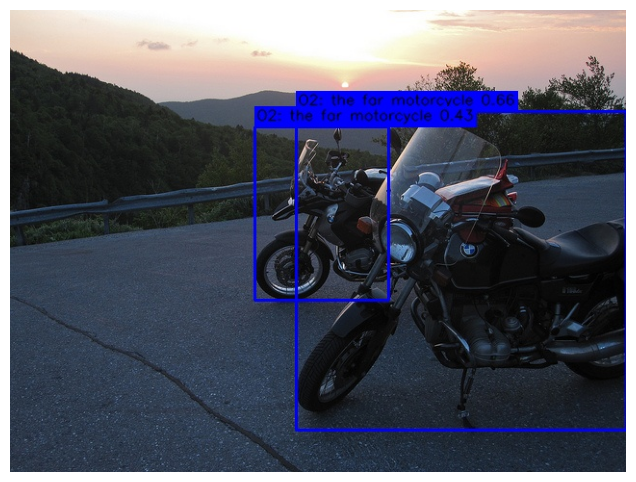

In [20]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = Path("/kaggle/input/datasets/lamnmh05/coco2017test/yoloe_rendered_bboxes/yoloe_rendered_bboxes")

image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp"]:
    image_paths.extend(IMAGE_DIR.rglob(ext))
    image_paths.extend(IMAGE_DIR.rglob(ext.upper()))

image_paths = sorted(list(set(image_paths)))

print("Total images:", len(image_paths))
print("First image:", image_paths[0])

# Lấy 1 ảnh để test
IMAGE_PATH = str(image_paths[0])

img = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

[INFO ] Processed Images Done taking 0.022002458572387695 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.46889400482177734 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008230209350585938 seconds
processed_images: (1, 378, 504, 3)
depth: (1, 378, 504)
conf: None
Original size: (640, 480)
Depth resized: (480, 640)
Final depth image size: (640, 480)


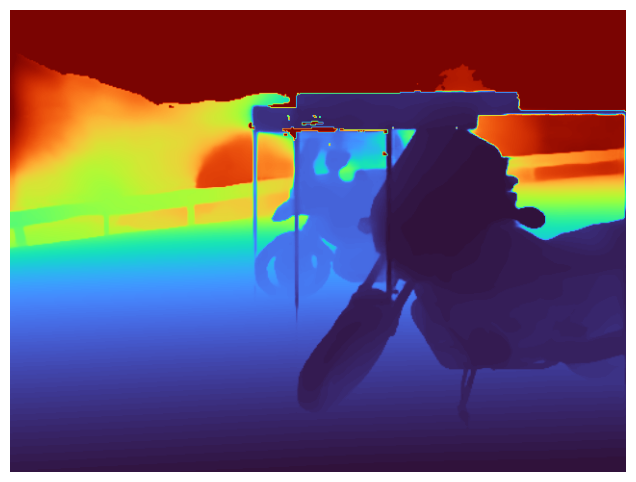

In [21]:
import torch
import numpy as np
import matplotlib.cm as cm
from PIL import Image
import matplotlib.pyplot as plt

PROCESS_RES = 504

with torch.inference_mode():
    prediction = model.inference(
        image=[IMAGE_PATH],  # dùng IMAGE_PATH, không dùng IMAGE_DIR
        process_res=PROCESS_RES,
        process_res_method="upper_bound_resize"
    )

print("processed_images:", prediction.processed_images.shape)
print("depth:", prediction.depth.shape)

conf = getattr(prediction, "conf", None)
print("conf:", None if conf is None else conf.shape)

# Lấy depth
depth = prediction.depth[0].astype(np.float32)

# Kích thước ảnh gốc
original_img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = original_img.size

print("Original size:", original_img.size)

# Xử lý NaN/Inf
valid = np.isfinite(depth)
depth_clean = depth.copy()

if valid.any():
    depth_clean[~valid] = np.nanmedian(depth_clean[valid])
else:
    depth_clean[:] = 0

# Resize depth về đúng kích thước ảnh gốc
try:
    resample_bilinear = Image.Resampling.BILINEAR
except AttributeError:
    resample_bilinear = Image.BILINEAR

depth_resized = Image.fromarray(depth_clean.astype(np.float32), mode="F")
depth_resized = depth_resized.resize((orig_w, orig_h), resample=resample_bilinear)
depth_resized = np.array(depth_resized).astype(np.float32)

print("Depth resized:", depth_resized.shape)

# Normalize
lo, hi = np.percentile(depth_resized, [1, 99])

if abs(hi - lo) < 1e-8:
    depth_norm = np.zeros_like(depth_resized, dtype=np.float32)
else:
    depth_clip = np.clip(depth_resized, lo, hi)
    depth_norm = (depth_clip - lo) / (hi - lo + 1e-8)

# Convert sang ảnh màu Depth Anything
depth_colored = cm.turbo(depth_norm)[:, :, :3]
depth_colored = (depth_colored * 255).astype(np.uint8)

depth_img = Image.fromarray(depth_colored)

print("Final depth image size:", depth_img.size)

plt.figure(figsize=(8, 6))
plt.imshow(depth_img)
plt.axis("off")
plt.show()

In [13]:
from tqdm.auto import tqdm
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.cm as cm
import torch
import os

OUTPUT_DIR = Path("/kaggle/working/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROCESS_RES = 504

try:
    resample_bilinear = Image.Resampling.BILINEAR
except AttributeError:
    resample_bilinear = Image.BILINEAR


def depth_to_colored_original_size(depth, original_size):
    """
    depth: numpy array H x W
    original_size: PIL size, dạng (width, height)
    return: PIL Image RGB, cùng kích thước ảnh gốc
    """

    depth = depth.astype(np.float32)

    # Xử lý NaN/Inf
    valid = np.isfinite(depth)
    depth_clean = depth.copy()

    if valid.any():
        depth_clean[~valid] = np.nanmedian(depth_clean[valid])
    else:
        depth_clean[:] = 0

    # Resize depth về đúng kích thước ảnh gốc
    orig_w, orig_h = original_size

    depth_resized = Image.fromarray(depth_clean.astype(np.float32), mode="F")
    depth_resized = depth_resized.resize((orig_w, orig_h), resample=resample_bilinear)
    depth_resized = np.array(depth_resized).astype(np.float32)

    # Normalize để nhìn đẹp hơn
    lo, hi = np.percentile(depth_resized, [1, 99])

    if abs(hi - lo) < 1e-8:
        depth_norm = np.zeros_like(depth_resized, dtype=np.float32)
    else:
        depth_clip = np.clip(depth_resized, lo, hi)
        depth_norm = (depth_clip - lo) / (hi - lo + 1e-8)

    # Colormap giống Depth Anything
    depth_colored = cm.turbo(depth_norm)[:, :, :3]
    depth_colored = (depth_colored * 255).astype(np.uint8)

    return Image.fromarray(depth_colored)


failed = []

for img_path in tqdm(image_paths, desc="Generating depth images"):
    img_path = Path(img_path)

    try:
        # Đọc kích thước ảnh gốc
        original_img = Image.open(img_path).convert("RGB")
        original_size = original_img.size

        with torch.inference_mode():
            prediction = model.inference(
                image=[str(img_path)],
                process_res=PROCESS_RES,
                process_res_method="upper_bound_resize"
            )

        depth = prediction.depth[0].astype(np.float32)

        depth_img = depth_to_colored_original_size(
            depth=depth,
            original_size=original_size
        )

        out_name = f"{img_path.stem}_depth.jpg"
        out_path = OUTPUT_DIR / out_name

        depth_img.save(out_path, quality=95)

    except Exception as e:
        failed.append({
            "image": str(img_path),
            "error": str(e)
        })

print("Done.")
print("Saved to:", OUTPUT_DIR)
print("Failed:", len(failed))

if failed:
    for item in failed[:10]:
        print(item)

Generating depth images:   0%|          | 0/1066 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.019225120544433594 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.4545323848724365 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0010905265808105469 seconds
[INFO ] Processed Images Done taking 0.019921064376831055 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.34870171546936035 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0007517337799072266 seconds
[INFO ] Processed Images Done taking 0.01952385902404785 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.35045909881591797 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0007500648498535156 seconds
[INFO ] Processed Images Done taking 0.021749496459960938 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.3481931686401367 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0007829666137695312 seconds
[INFO ] Processed I

Total output files: 1066
/kaggle/working/output/000000000178_depth.jpg
/kaggle/working/output/000000000205_depth.jpg
/kaggle/working/output/000000000453_depth.jpg
/kaggle/working/output/000000000456_depth.jpg
/kaggle/working/output/000000000463_depth.jpg
/kaggle/working/output/000000000686_depth.jpg
/kaggle/working/output/000000000725_depth.jpg
/kaggle/working/output/000000000771_depth.jpg
/kaggle/working/output/000000000870_depth.jpg
/kaggle/working/output/000000001152_depth.jpg


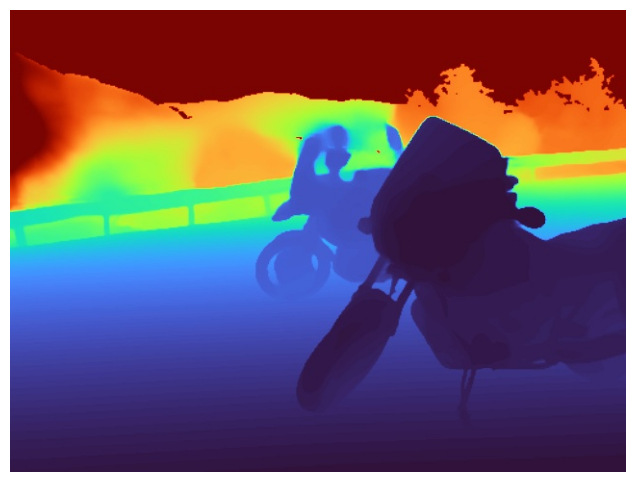

In [16]:
output_files = sorted(OUTPUT_DIR.glob("*_depth.jpg"))

print("Total output files:", len(output_files))

for p in output_files[:10]:
    print(p)

# Preview 1 ảnh depth output
preview_path = output_files[0]

img = Image.open(preview_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [17]:
import shutil
from pathlib import Path

zip_path = "/kaggle/working/depth_output"

# Nếu file zip cũ tồn tại thì xóa
old_zip = Path(zip_path + ".zip")
if old_zip.exists():
    old_zip.unlink()

shutil.make_archive(
    base_name=zip_path,
    format="zip",
    root_dir="/kaggle/working",
    base_dir="output"
)

print("Created:", zip_path + ".zip")

Created: /kaggle/working/depth_output.zip


In [19]:
!ls -lh /kaggle/working/depth_output.zip

-rw-r--r-- 1 root root 47M Jul  4 18:02 /kaggle/working/depth_output.zip
